In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('XAUUSD_M15_20241121.csv', parse_dates=["Date"], index_col=0)

In [3]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']), 1,
#     np.where((df['stoch_k'] < df['stoch_d']), -1, 0)
# )

# df["rsi"] = ta.rsi(df["Close"], length=13)
# rsi_upper = 70
# rsi_lower = 30
# df["position_rsi"] = np.where(df.rsi > rsi_upper, -1, np.nan) # 1. overbought -> go short
# df["position_rsi"] = np.where(df.rsi < rsi_lower, 1, df.position_rsi) # 2. oversold -> go long
# df.position_rsi = df.position_rsi.fillna(0) # 3. where 1 & 2 isn´t applicable -> neutral

df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
df["position"] = df.position.ffill().fillna(0)
df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [ ]:
# df_filtered = df[((df['position'] == 1) & (df['position_rsi'] == 1)) | ((df['position'] == -1) & (df['position_rsi'] == -1))].copy()

In [ ]:
# df_filtered['position'] = df_filtered['position'].map({-1: 0, 1: 1})
# df.dropna(inplace=True)
# accuracy = accuracy_score(df_filtered.target, df_filtered.position) * 100
# accuracy

53.292361720807726

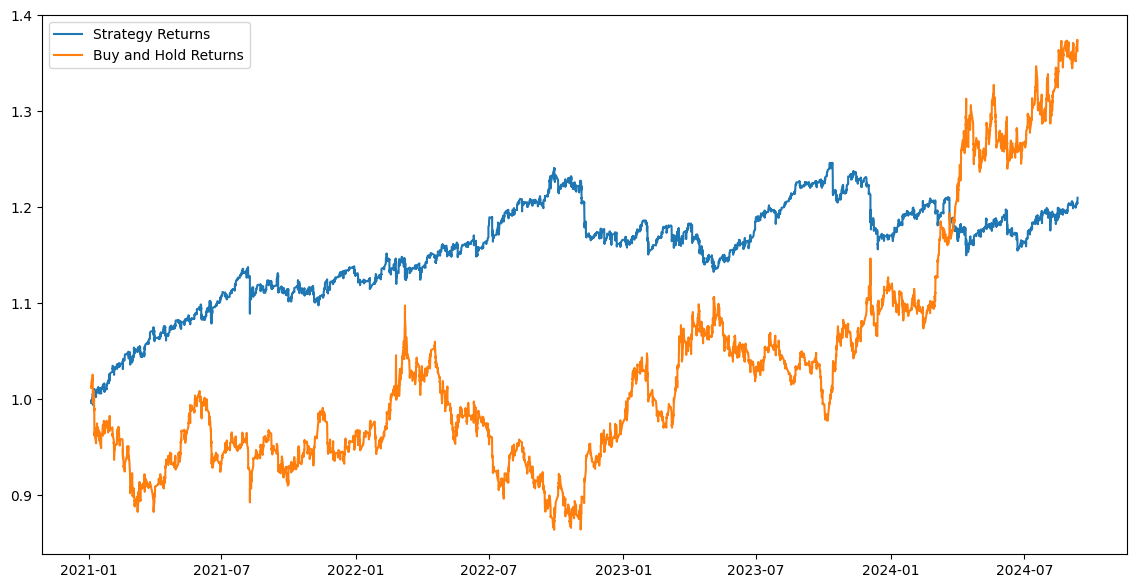

In [ ]:
# # strategy
# df_filtered['position'] = df_filtered['position'].map({0: -1, 1: 1})
# df_filtered['strategy'] = df_filtered['position'] * df_filtered['s_returns']
# df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# # plot
# plt.figure(figsize=(14,7))
# plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
# plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
# plt.legend()
# plt.show()

In [4]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent",'distance', 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 54.80
Test Accuracy: 53.01
Total Accuracy: 54.44


In [30]:
X_wlr_th = 0.914
X_raw_accuracy_th = 53
X_filtered_accuracy_th = 58
X_sharp_ratio_th = 12
X_max_dd_th = 0.07
X_position_count_th = 16000
X_cumulative_th = 4.5
X_annual_th = 2.3

In [31]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': X_wlr_th,
    'raw_accuracy': X_raw_accuracy_th,
    'filtered_accuracy': X_filtered_accuracy_th,
    'sharp_ratio': X_sharp_ratio_th,
    'max_dd': X_max_dd_th,
    'position_count': X_position_count_th,
    'cumulative': X_cumulative_th,
    'annual' : X_annual_th}
joblib.dump(objects_to_save, 'U_XU.joblib')

['U_XU.joblib']

# Filter and Evaluations

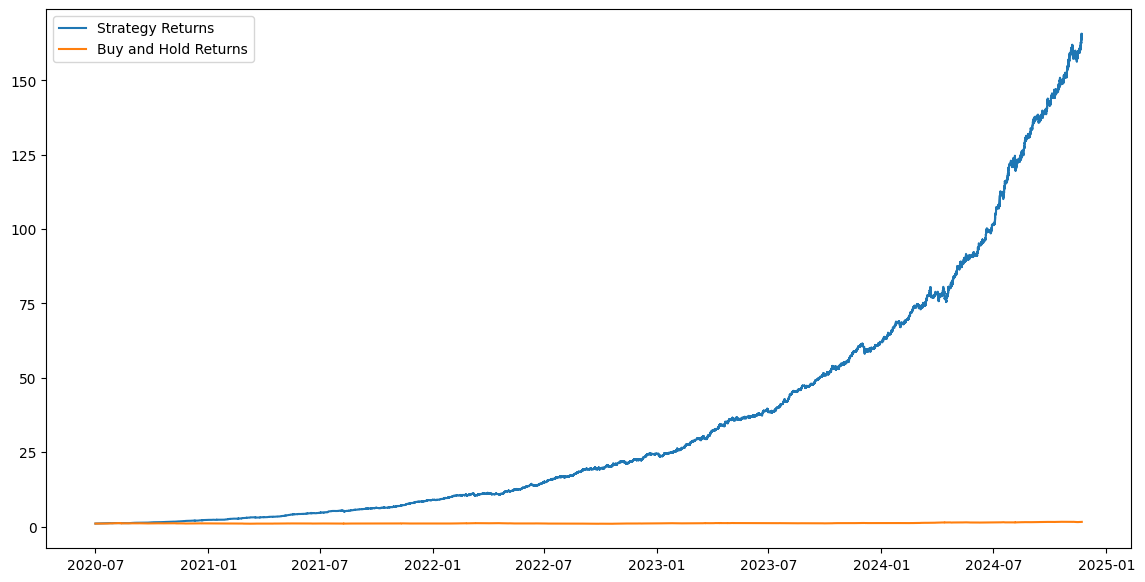

In [6]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [7]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 1.28
Annualized Sharpe Ratio: 8.34
Maximum Drawdown: -0.07


In [8]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
1    49999
0    49580
Name: count, dtype: int64
pred
-1    53820
 1    45759
Name: count, dtype: int64
position
 0.0    45484
-1.0    27961
 1.0    26134
Name: count, dtype: int64


In [9]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.98613723)

In [10]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,...,9.957900e+04,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,99579.000000,45195.000000,53995.000000,99579.000000
mean,1958.063414,1959.292853,1956.802163,1958.068386,0.000005,0.502104,0.000005,1.128922,0.000795,0.009791,...,2.762075e-01,-0.080951,0.500134,0.499866,0.519411,0.000051,35.662605,0.000635,0.000626,0.032066
std,241.480121,241.660235,241.302140,241.489769,0.000975,0.499998,0.000974,0.151025,0.000565,1.026763,...,4.176589e-01,0.996723,0.025648,0.025648,0.016765,0.000972,40.723699,0.000808,0.000687,0.033766
min,1616.550000,1618.700000,1614.700000,1616.590000,-0.039962,0.000000,-0.039962,0.932179,0.000063,-3.758429,...,0.000000e+00,-1.000000,0.266682,0.225548,0.500000,-0.039962,0.998346,0.000004,0.000004,-0.007029
25%,1801.825000,1802.830000,1800.760000,1801.810000,-0.000413,0.000000,-0.000411,1.028205,0.000452,-0.664298,...,3.559350e-14,-1.000000,0.483560,0.484315,0.509682,-0.000349,5.270131,0.000179,0.000199,0.012471
50%,1893.670000,1894.800000,1892.490000,1893.660000,0.000010,1.000000,0.000005,1.079093,0.000651,0.014044,...,2.053143e-05,-1.000000,0.502876,0.497124,0.516018,0.000062,19.312360,0.000402,0.000441,0.025233
75%,1996.040000,1997.560000,1994.660000,1996.065000,0.000433,1.000000,0.000431,1.158193,0.000961,0.684523,...,7.704089e-01,1.000000,0.515685,0.516440,0.524228,0.000488,53.472636,0.000797,0.000824,0.041768
max,2788.940000,2789.970000,2788.450000,2788.960000,0.025853,1.000000,0.025853,1.639908,0.015681,4.036516,...,9.999982e-01,1.000000,0.774452,0.733318,0.774452,0.013642,165.655968,0.039962,0.013642,0.545734


In [11]:
df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [12]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-07-01 10:15:00,1783.73,1787.33,1783.47,1787.20,0.001945,0,-0.000179,1.002869,0.000757,2.568286,...,2.426430e-11,-1,0.531180,0.468820,0.531180,0.000179,1.004865,NaN,0.000179,0.055769
2020-07-01 10:45:00,1786.88,1789.08,1786.36,1788.68,0.001007,0,-0.000498,1.003380,0.000815,1.236096,...,5.297963e-10,-1,0.524796,0.475204,0.524796,0.000498,1.006379,NaN,0.000498,0.042912
2020-07-01 11:15:00,1787.81,1788.73,1787.04,1788.63,0.000470,0,-0.000844,1.003004,0.000837,0.561601,...,2.685502e-09,-1,0.514740,0.485260,0.514740,0.000844,1.007702,NaN,0.000844,0.022658
2020-07-01 11:45:00,1787.12,1788.82,1786.83,1787.68,0.000313,0,-0.000990,1.002326,0.000923,0.339611,...,1.362241e-12,-1,0.508514,0.491486,0.508514,0.000990,1.009016,NaN,0.000990,0.010120
2020-07-01 12:15:00,1785.92,1787.68,1785.45,1787.46,0.000868,0,-0.000101,1.003095,0.000761,1.140051,...,3.028536e-09,-1,0.523975,0.476025,0.523975,0.000101,1.009994,NaN,0.000101,0.041259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-21 21:00:00,2671.10,2672.57,2670.28,2672.29,0.000446,1,0.000150,1.572685,0.000629,0.707850,...,1.470678e-05,-1,0.521415,0.478585,0.521415,-0.000150,165.421640,0.00015,NaN,0.036102
2024-11-21 21:15:00,2672.29,2673.32,2671.91,2672.69,0.000150,0,-0.000662,1.571643,0.000570,0.262529,...,2.917450e-04,-1,0.528564,0.471436,0.528564,0.000662,165.531227,NaN,0.000662,0.050501
2024-11-21 22:00:00,2669.27,2670.37,2667.74,2669.52,0.000090,0,-0.000243,1.570438,0.000424,0.212021,...,9.319041e-01,-1,0.508378,0.491622,0.508378,0.000243,165.484783,NaN,0.000243,0.009845


In [13]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

54.95108162090795

In [14]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
print(df_filtered.position.value_counts())

target
0    14850
1    14689
Name: count, dtype: int64
pred
0    16387
1    13152
Name: count, dtype: int64
position
-1.0    16387
 1.0    13152
Name: count, dtype: int64


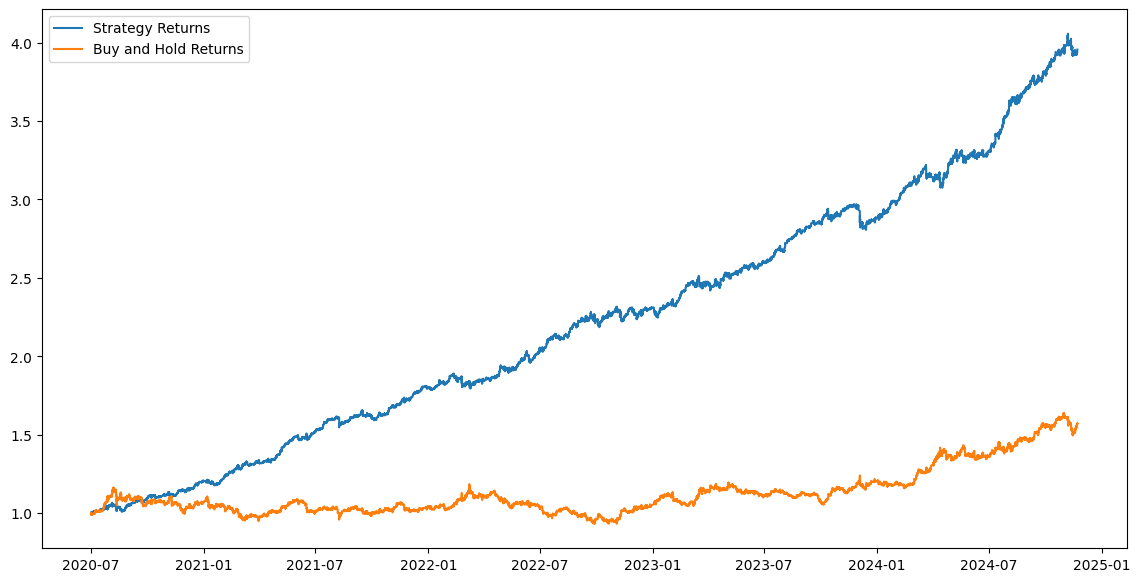

In [15]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [16]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 1.16
Annualized Sharpe Ratio: 6.66
Maximum Drawdown: -0.06


In [17]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.9386177)

In [18]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,...,2.953900e+04,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,29539.000000,13274.000000,16170.000000,29539.000000
mean,1958.908587,1960.302654,1957.442689,1958.879539,-0.000018,0.497275,0.000002,1.129309,0.000858,0.011780,...,2.220124e-01,-0.109516,0.500162,0.499838,0.521175,0.000047,2.222182,0.000722,0.000678,0.011036
std,243.211558,243.455804,243.037549,243.279728,0.001185,0.500001,0.001105,0.152100,0.000598,1.166536,...,3.888774e-01,0.994002,0.027577,0.027577,0.017667,0.001104,0.804483,0.000978,0.000746,0.036489
min,1618.310000,1618.810000,1616.040000,1616.590000,-0.039962,0.000000,-0.039962,0.933053,0.000101,-3.758429,...,0.000000e+00,-1.000000,0.378514,0.245744,0.500000,-0.039962,1.000179,0.000004,0.000004,-0.032698
25%,1801.355000,1802.375000,1799.930000,1801.250000,-0.000503,0.000000,-0.000455,1.028005,0.000489,-0.726802,...,1.416511e-17,-1.000000,0.482427,0.483300,0.510611,-0.000380,1.587422,0.000198,0.000219,-0.010783
50%,1893.190000,1894.450000,1891.780000,1893.100000,0.000016,0.000000,0.000000,1.078361,0.000703,0.025279,...,1.547637e-06,-1.000000,0.504273,0.495727,0.517114,0.000073,2.206145,0.000445,0.000476,0.002650
75%,1995.830000,1997.475000,1994.570000,1996.030000,0.000516,1.000000,0.000466,1.157731,0.001040,0.778501,...,2.146096e-01,1.000000,0.516700,0.517573,0.526827,0.000534,2.860693,0.000900,0.000891,0.022710
max,2787.020000,2788.630000,2785.920000,2788.220000,0.025853,1.000000,0.025853,1.639419,0.015671,4.036516,...,9.999927e-01,1.000000,0.754256,0.621486,0.754256,0.012512,4.055891,0.039962,0.012512,0.492441


In [19]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-07-01 01:45:00,1781.88,1782.41,1781.15,1781.75,-0.000073,0,-0.000157,0.999826,0.000826,-0.088361,...,0.000000e+00,-1,0.557052,0.442948,0.557052,0.000157,1.000157,NaN,0.000157,0.107878
2020-07-01 02:00:00,1781.71,1781.95,1781.31,1781.47,-0.000157,1,0.000544,1.000371,0.000826,-0.190268,...,8.718794e-08,-1,0.500629,0.499371,0.500629,-0.000544,0.999613,0.000544,NaN,-0.005763
2020-07-01 02:15:00,1781.47,1783.24,1781.42,1782.44,0.000544,1,0.000567,1.000938,0.000836,0.651374,...,4.878627e-09,-1,0.517010,0.482990,0.517010,-0.000567,0.999046,0.000567,NaN,0.027230
2020-07-01 02:30:00,1782.44,1783.47,1782.44,1783.45,0.000567,1,0.000336,1.001274,0.000728,0.778678,...,2.190903e-07,-1,0.521663,0.478337,0.521663,-0.000336,0.998710,0.000336,NaN,0.036602
2020-07-01 02:45:00,1783.44,1784.34,1783.28,1784.05,0.000336,0,-0.000684,1.000590,0.000692,0.486462,...,2.136740e-06,-1,0.515510,0.484490,0.515510,0.000684,0.999394,NaN,0.000684,0.024209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-21 22:45:00,2669.94,2670.72,2669.43,2669.87,-0.000041,1,0.000577,1.571933,0.000423,-0.097413,...,9.606177e-01,1,0.442026,0.557974,0.557974,0.000577,165.655968,NaN,0.000577,0.109733
2024-11-21 23:00:00,2669.91,2671.71,2669.57,2671.41,0.000577,0,-0.000401,1.571303,0.000447,1.290121,...,5.401191e-01,1,0.497410,0.502590,0.502590,-0.000401,165.589630,0.000401,NaN,-0.001812
2024-11-21 23:15:00,2671.42,2671.75,2670.17,2670.34,-0.000401,0,-0.000292,1.570844,0.000456,-0.878770,...,9.888709e-01,1,0.474803,0.525197,0.525197,-0.000292,165.541268,0.000292,NaN,0.043719


In [20]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy

58.31646113258482

In [21]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2020-07-01 10:15:00,1783.73,1787.33,1783.47,1787.20,0.001945,0,-0.000179,1.002869,0.000757,2.568286,...,2.426430e-11,0,0.531180,0.468820,0.531180,0.000179,1.000179,NaN,0.000179,0.031700
2020-07-01 10:45:00,1786.88,1789.08,1786.36,1788.68,0.001007,0,-0.000498,1.003380,0.000815,1.236096,...,5.297963e-10,0,0.524796,0.475204,0.524796,0.000498,1.000677,NaN,0.000498,0.018516
2020-07-01 12:15:00,1785.92,1787.68,1785.45,1787.46,0.000868,0,-0.000101,1.003095,0.000761,1.140051,...,3.028536e-09,0,0.523975,0.476025,0.523975,0.000101,1.002615,NaN,0.000101,0.016820
2020-07-01 12:45:00,1787.28,1788.52,1786.25,1787.70,0.000235,0,-0.000431,1.002899,0.000659,0.356540,...,8.543006e-06,0,0.516365,0.483635,0.516365,0.000431,1.002811,NaN,0.000431,0.001101
2020-07-01 13:15:00,1786.88,1788.43,1786.56,1787.57,0.000358,0,-0.000873,1.002383,0.000641,0.558381,...,1.698116e-05,0,0.519549,0.480451,0.519549,0.000873,1.003687,NaN,0.000873,0.007678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-21 13:30:00,2670.91,2673.35,2670.91,2672.91,0.000775,0,-0.000894,1.571390,0.000433,1.791089,...,2.177312e-03,0,0.633035,0.366965,0.633035,0.000894,3.938274,NaN,0.000894,0.242072
2024-11-21 14:00:00,2670.50,2672.54,2669.88,2671.39,0.000326,0,-0.002736,1.567606,0.000536,0.608252,...,3.572634e-03,0,0.522475,0.477525,0.522475,0.002736,3.949065,NaN,0.002736,0.013722
2024-11-21 20:00:00,2669.03,2672.70,2669.03,2671.67,0.000989,0,-0.000255,1.571684,0.000874,1.131108,...,9.741766e-12,0,0.525316,0.474684,0.525316,0.000255,3.950071,NaN,0.000255,0.019590


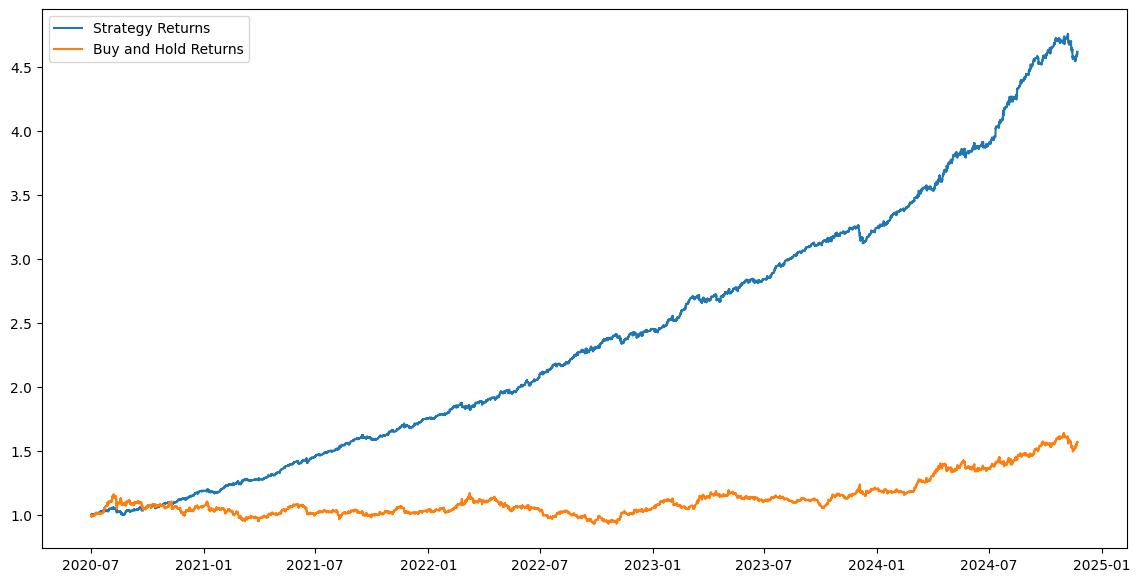

In [22]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [23]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.91538544)

In [24]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 2.34
Annualized Sharpe Ratio: 12.75
Maximum Drawdown: -0.06
